<a href="https://colab.research.google.com/github/sunandha2/Urban-Mobility-Intelligence-Uber-Analysis/blob/main/Uber_Pickup_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  UBER NYC DEMAND PREDICTION — PRODUCTION-GRADE PROJECT
#  Dataset: uber-raw-data-apr14.csv
#  Author: k sunandha
#  Objective: Predict hourly ride demand using temporal &
#             spatial features with proper ML methodology
# CELL 1 — Install & Import Libraries
# !pip install folium xgboost lightgbm scikit-learn seaborn pandas numpy matplotlib

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                              mean_absolute_percentage_error, r2_score)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import lightgbm as lgb

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Libraries loaded successfully")

Libraries loaded successfully


Load & Validate Data

In [45]:
df = pd.read_csv("uber-raw-data-apr14[1].csv")

In [46]:
# Data quality report
print("=" * 50)
print("DATA QUALITY REPORT")
print("=" * 50)
print(f"Total records      : {len(df):,}")
print(f"Columns            : {list(df.columns)}")
print(f"Missing values     :\n{df.isnull().sum()}")
print(f"Duplicate rows     : {df.duplicated().sum()}")
print(f"\nDate range         : {df['Date/Time'].min()} → {df['Date/Time'].max()}")
print(f"Lat range          : {df['Lat'].min():.4f} → {df['Lat'].max():.4f}")
print(f"Lon range          : {df['Lon'].min():.4f} → {df['Lon'].max():.4f}")
print(f"Unique bases       : {df['Base'].nunique()} → {df['Base'].unique()}")


DATA QUALITY REPORT
Total records      : 564,516
Columns            : ['Date/Time', 'Lat', 'Lon', 'Base']
Missing values     :
Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64
Duplicate rows     : 7749

Date range         : 4/1/2014 0:00:00 → 4/9/2014 9:59:00
Lat range          : 40.0729 → 42.1166
Lon range          : -74.7733 → -72.0666
Unique bases       : 5 → ['B02512' 'B02598' 'B02617' 'B02682' 'B02764']


Data Cleaning

In [47]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

In [48]:
nyc_bounds = {'lat_min': 40.4, 'lat_max': 40.95,
               'lon_min': -74.3, 'lon_max': -73.7}

before = len(df)
df = df[
    (df['Lat'] >= nyc_bounds['lat_min']) & (df['Lat'] <= nyc_bounds['lat_max']) &
    (df['Lon'] >= nyc_bounds['lon_min']) & (df['Lon'] <= nyc_bounds['lon_max'])
]
print(f"Removed {before - len(df):,} geographic outliers ({(before-len(df))/before*100:.2f}%)")
print(f"Clean dataset: {len(df):,} records")


Removed 2,035 geographic outliers (0.36%)
Clean dataset: 562,481 records


 Feature Engineering (The Core)

In [49]:
def engineer_features(df):
    """
    Full temporal + spatial feature engineering pipeline.
    Returns enriched DataFrame ready for modelling.
    """
    df = df.copy()

In [51]:
    # Temporal features
    df['hour']        = df['Date/Time'].dt.hour
    df['day']         = df['Date/Time'].dt.day
    df['weekday']     = df['Date/Time'].dt.weekday      # 0=Mon, 6=Sun
    df['week']        = df['Date/Time'].dt.isocalendar().week.astype(int)
    df['month']       = df['Date/Time'].dt.month
    df['dayofyear']   = df['Date/Time'].dt.dayofyear

In [52]:
    # Cyclical encoding (critical for time!)
    # Raw hour 0 and hour 23 are numerically far apart but temporally close.
    # Sine/cosine encoding fixes this — standard practice in time-series ML.
    df['hour_sin']    = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos']    = np.cos(2 * np.pi * df['hour'] / 24)
    df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
    df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)
    df['month_sin']   = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos']   = np.cos(2 * np.pi * df['month'] / 12)

In [53]:
    # Calendar flags
    df['is_weekend']  = (df['weekday'] >= 5).astype(int)
    df['is_rush_am']  = ((df['hour'] >= 7)  & (df['hour'] <= 9)).astype(int)
    df['is_rush_pm']  = ((df['hour'] >= 16) & (df['hour'] <= 19)).astype(int)
    df['is_night']    = ((df['hour'] >= 22) | (df['hour'] <= 5)).astype(int)
    df['is_midday']   = ((df['hour'] >= 11) & (df['hour'] <= 14)).astype(int)

In [54]:
    #  Time buckets (for EDA / readable grouping)
    df['time_bucket'] = pd.cut(
        df['hour'],
        bins=[-1, 5, 9, 12, 16, 19, 23],
        labels=['Late Night', 'AM Rush', 'Mid Morning', 'Midday', 'PM Rush', 'Evening']
    )

In [55]:
    # Spatial clustering (demand zones)
    # KMeans on lat/lon to create geographic demand hotspot zones.
    # 8 clusters chosen to approximate Manhattan neighbourhoods + outer zones.
    kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
    df['zone'] = kmeans.fit_predict(df[['Lat', 'Lon']])


In [68]:
def engineer_features(df):
    df = df.copy()

    # (other features...)

    df['base_encoded'] = df['Base'].astype('category').cat.codes

    return df, kmeans   #  INSIDE function


# OUTSIDE function
df, kmeans = engineer_features(df)
print(f"Feature engineering complete. Shape: {df.shape}")
print(f"\nNew features added:")
new_cols = ['hour_sin','hour_cos','weekday_sin','weekday_cos',
            'is_weekend','is_rush_am','is_rush_pm','is_night',
            'zone','base_encoded','time_bucket']
for c in new_cols:
    print(f"  • {c}")

Feature engineering complete. Shape: (562481, 24)

New features added:
  • hour_sin
  • hour_cos
  • weekday_sin
  • weekday_cos
  • is_weekend
  • is_rush_am
  • is_rush_pm
  • is_night
  • zone
  • base_encoded
  • time_bucket


Build Hourly Demand Time Series

In [69]:
# We predict ACTUAL TRIP COUNTS per hour per zone — a real regression problem.
# This avoids the data leakage issue of deriving binary labels from features.
hourly = (df.groupby(['day', 'weekday', 'week', 'hour', 'zone',
                       'hour_sin', 'hour_cos',
                       'weekday_sin', 'weekday_cos',
                       'month_sin', 'month_cos',
                       'is_weekend', 'is_rush_am', 'is_rush_pm',
                       'is_night', 'is_midday', 'base_encoded'])
          .size()
          .reset_index(name='trip_count'))


In [70]:
# Sort by day + hour for temporal integrity
hourly = hourly.sort_values(['day', 'hour']).reset_index(drop=True)

print("=" * 50)
print("HOURLY DEMAND DATASET")
print("=" * 50)
print(f"Rows (hour×zone combinations): {len(hourly):,}")
print(f"\nTrip count distribution:")
print(hourly['trip_count'].describe().round(2))

HOURLY DEMAND DATASET
Rows (hour×zone combinations): 23,127

Trip count distribution:
count    23127.00
mean        24.32
std         46.17
min          1.00
25%          3.00
50%          8.00
75%         22.00
max        498.00
Name: trip_count, dtype: float64


Add Lag Features (Time-Series Context)

In [75]:
def add_lag_features(hourly_df):
    """
    Lag features give the model memory of past demand.
    These are among the most predictive features in demand forecasting.
    """
    df_lag = hourly_df.copy()
    # Sort per zone before computing lags
    df_lag = df_lag.sort_values(['zone', 'day', 'hour']).reset_index(drop=True)

    for zone in df_lag['zone'].unique():
        mask = df_lag['zone'] == zone
        zone_data = df_lag.loc[mask, 'trip_count']
                # Lag features — demand at previous time steps
        df_lag.loc[mask, 'lag_1h']  = zone_data.shift(1)   # 1 hour ago
        df_lag.loc[mask, 'lag_2h']  = zone_data.shift(2)   # 2 hours ago
        df_lag.loc[mask, 'lag_24h'] = zone_data.shift(24)  # same hour yesterday

        # Rolling statistics — demand trend
        df_lag.loc[mask, 'rolling_3h_mean']  = zone_data.shift(1).rolling(3).mean()
        df_lag.loc[mask, 'rolling_6h_mean']  = zone_data.shift(1).rolling(6).mean()
        df_lag.loc[mask, 'rolling_3h_std']   = zone_data.shift(1).rolling(3).std()
        df_lag.loc[mask, 'rolling_24h_mean'] = zone_data.shift(1).rolling(24).mean()

    df_lag = df_lag.dropna().reset_index(drop=True)
    return df_lag

hourly = add_lag_features(hourly)
print(f"After adding lag features: {len(hourly):,} rows (NaN rows dropped)")
print(f"\nFinal feature set:")
feature_cols = ['hour_sin', 'hour_cos', 'weekday_sin', 'weekday_cos',
                'month_sin', 'month_cos', 'is_weekend', 'is_rush_am',
                'is_rush_pm', 'is_night', 'is_midday', 'zone',
                'base_encoded', 'lag_1h', 'lag_2h', 'lag_24h',
                'rolling_3h_mean', 'rolling_6h_mean', 'rolling_3h_std',
                'rolling_24h_mean']
for c in feature_cols:
    print(f"  • {c}")




After adding lag features: 22,935 rows (NaN rows dropped)

Final feature set:
  • hour_sin
  • hour_cos
  • weekday_sin
  • weekday_cos
  • month_sin
  • month_cos
  • is_weekend
  • is_rush_am
  • is_rush_pm
  • is_night
  • is_midday
  • zone
  • base_encoded
  • lag_1h
  • lag_2h
  • lag_24h
  • rolling_3h_mean
  • rolling_6h_mean
  • rolling_3h_std
  • rolling_24h_mean


EDA: Deep Exploratory Analysis

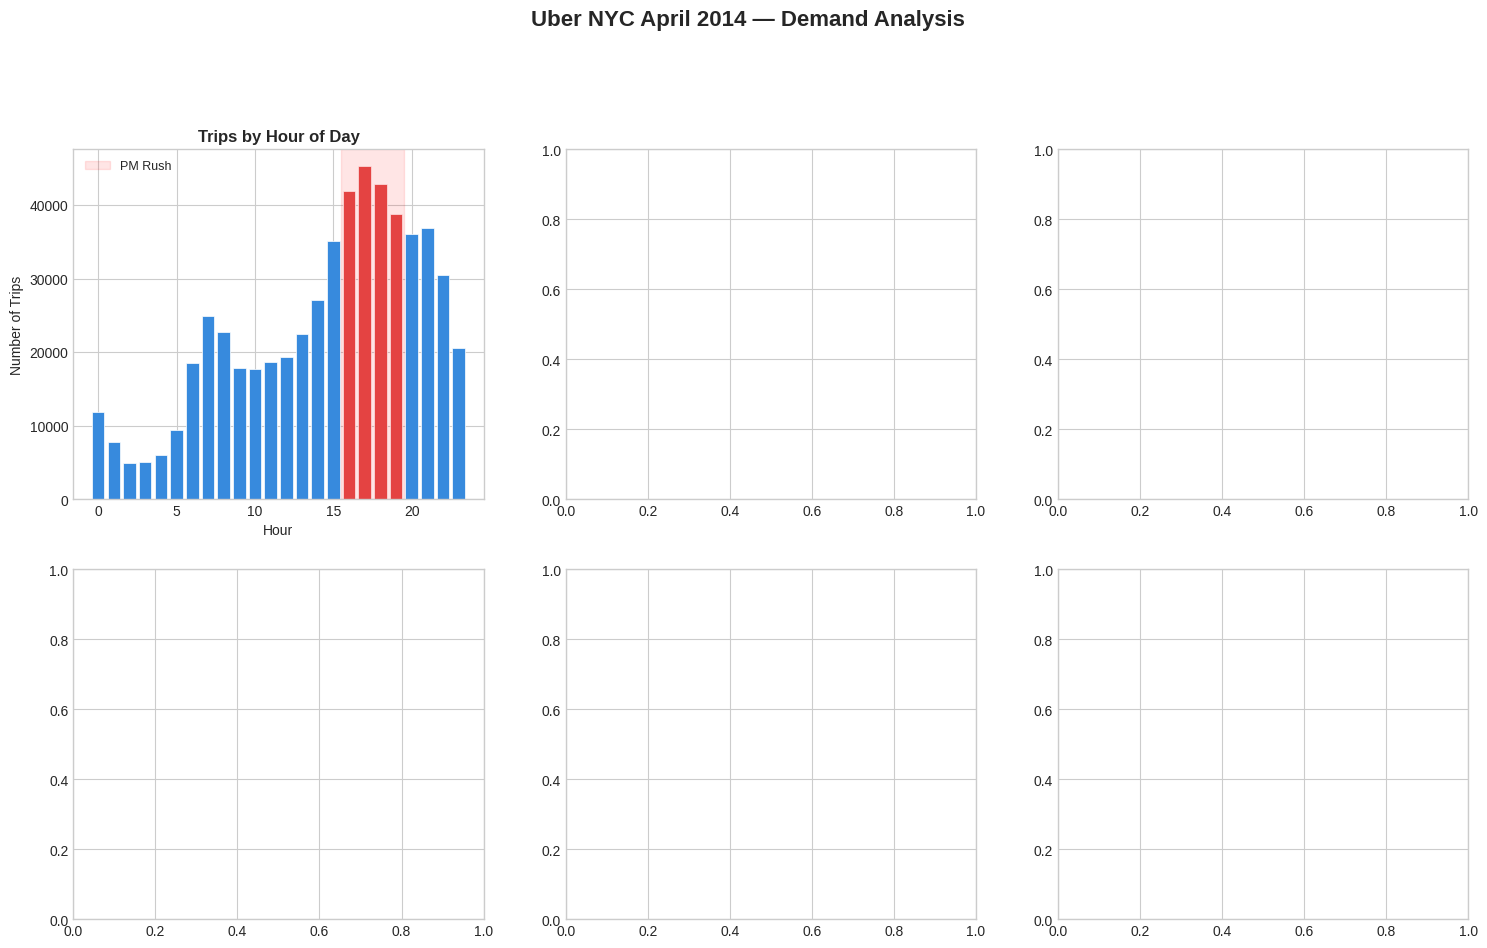

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Uber NYC April 2014 — Demand Analysis', fontsize=16, fontweight='bold', y=1.02)

# Plot 1: Trips by Hour
hour_counts = df['hour'].value_counts().sort_index()
axes[0,0].bar(hour_counts.index, hour_counts.values,
              color=['#E24B4A' if (16 <= h <= 19) else '#378ADD' for h in hour_counts.index],
              edgecolor='white', linewidth=0.5)
axes[0,0].set_title('Trips by Hour of Day', fontweight='bold')
axes[0,0].set_xlabel('Hour')
axes[0,0].set_ylabel('Number of Trips')
axes[0,0].axvspan(15.5, 19.5, alpha=0.1, color='red', label='PM Rush')
axes[0,0].legend(fontsize=9)

Text(0, 0.5, 'Number of Trips')

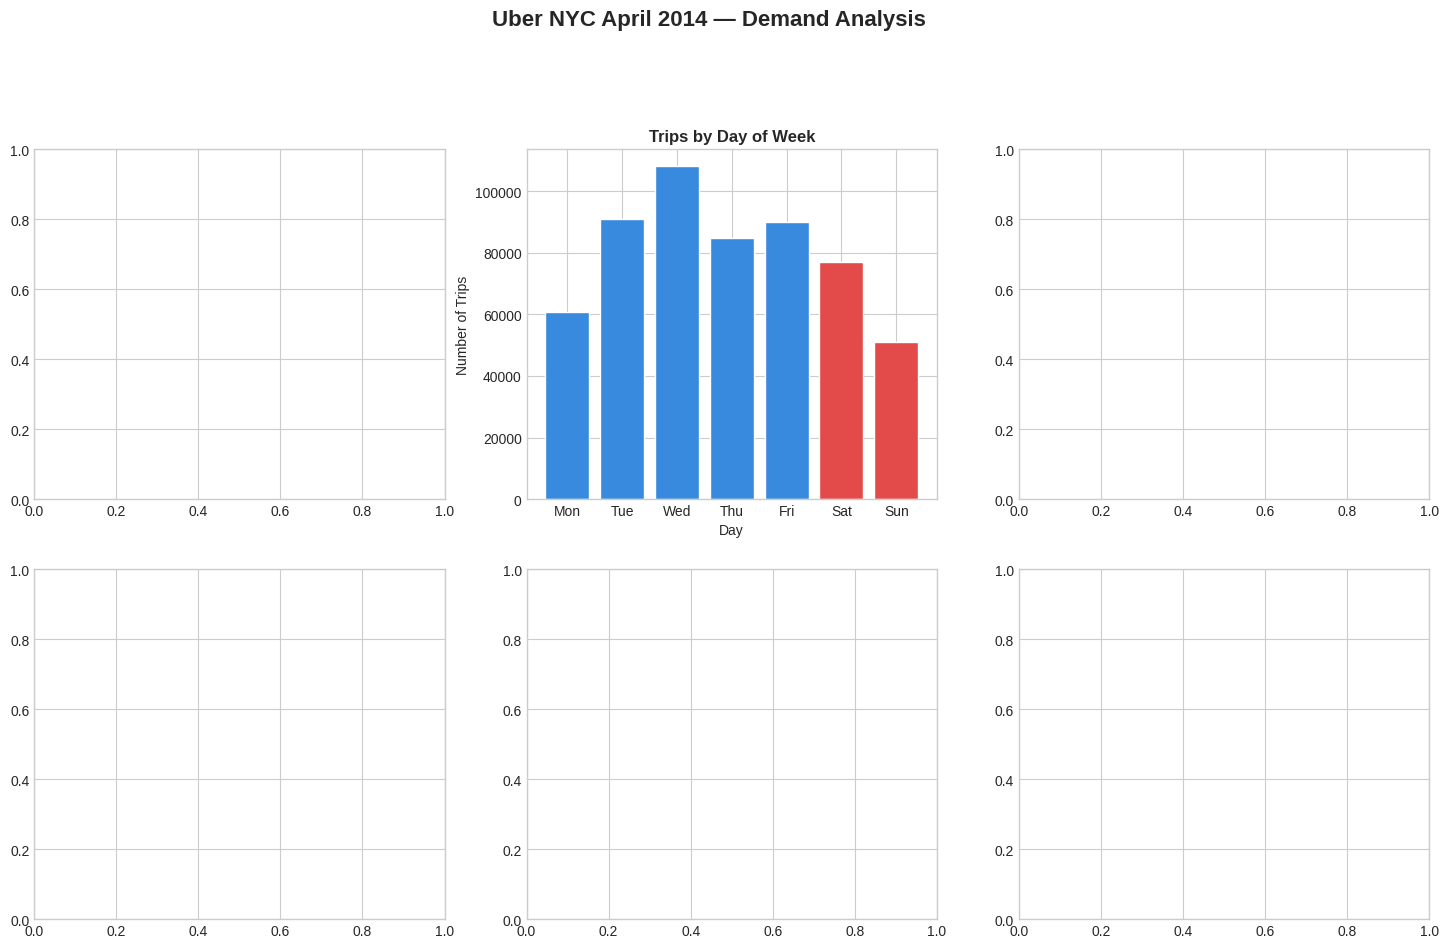

In [79]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Uber NYC April 2014 — Demand Analysis', fontsize=16, fontweight='bold', y=1.02)
# Plot 2: Trips by Weekday
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
day_counts = df['weekday'].value_counts().sort_index()
colors_day = ['#E24B4A' if i >= 5 else '#378ADD' for i in range(7)]
axes[0,1].bar(day_names, day_counts.values, color=colors_day, edgecolor='white')
axes[0,1].set_title('Trips by Day of Week', fontweight='bold')
axes[0,1].set_xlabel('Day')
axes[0,1].set_ylabel('Number of Trips')

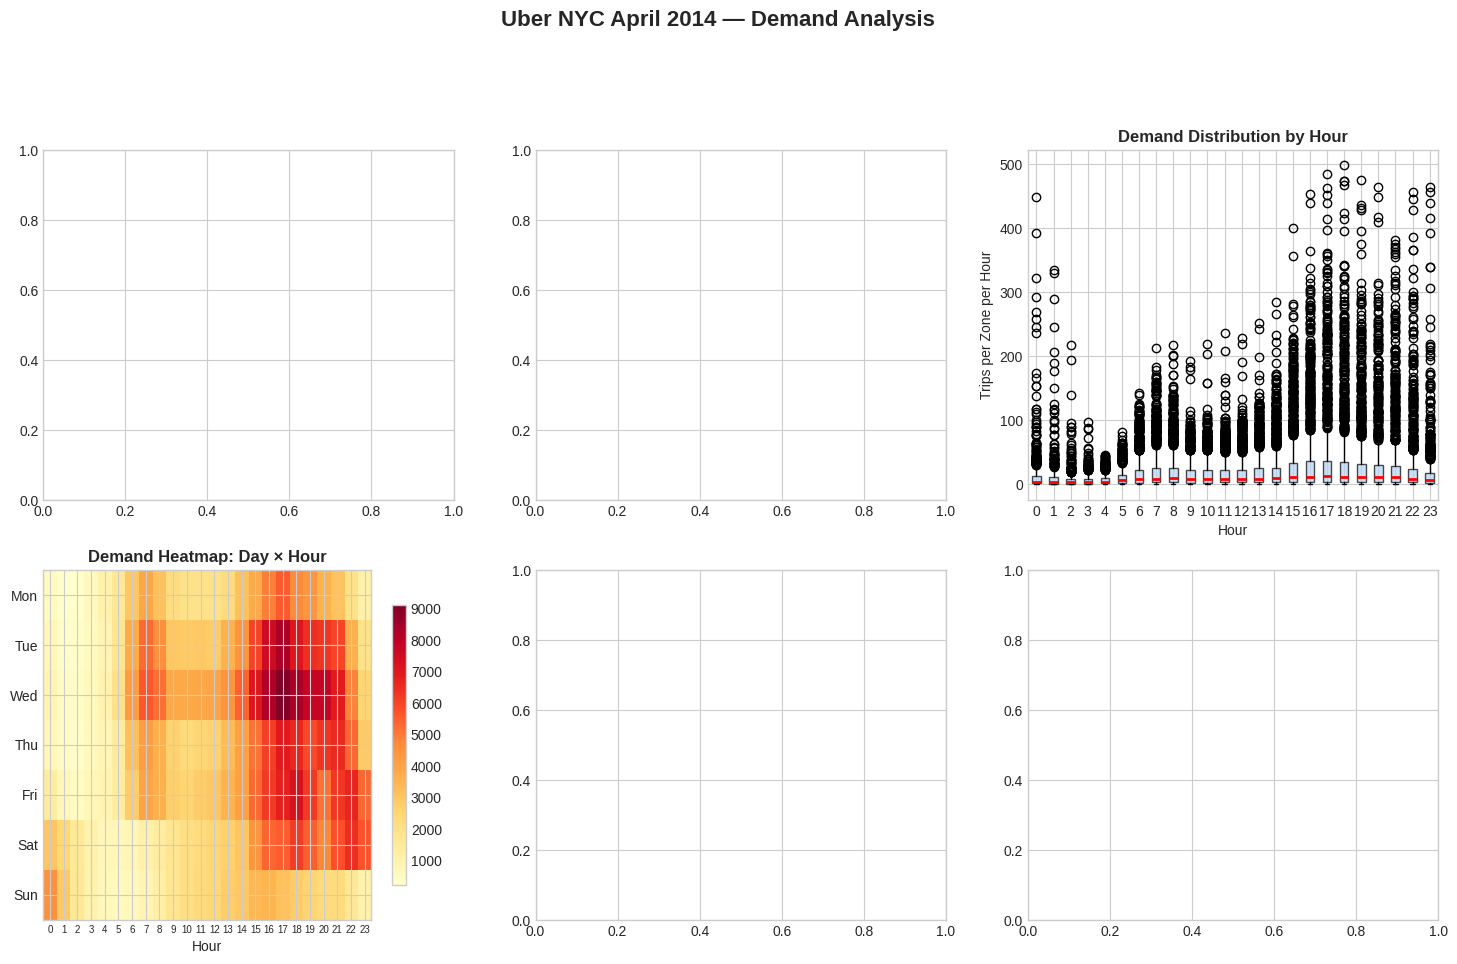

In [80]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Uber NYC April 2014 — Demand Analysis', fontsize=16, fontweight='bold', y=1.02)
# Plot 3: Hourly demand boxplot (distribution by hour)
hour_trip_data = hourly.groupby('hour')['trip_count']
boxes = [hour_trip_data.get_group(h).values for h in sorted(hourly['hour'].unique())]
axes[0,2].boxplot(boxes, positions=sorted(hourly['hour'].unique()),
                   patch_artist=True, medianprops={'color': 'red', 'linewidth': 2},
                   boxprops={'facecolor': '#B5D4F4', 'alpha': 0.7})
axes[0,2].set_title('Demand Distribution by Hour', fontweight='bold')
axes[0,2].set_xlabel('Hour')
axes[0,2].set_ylabel('Trips per Zone per Hour')

# Plot 4: Heatmap Weekday × Hour
pivot = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
pivot.index = day_names
im = axes[1,0].imshow(pivot.values, cmap='YlOrRd', aspect='auto')
axes[1,0].set_xticks(range(24))
axes[1,0].set_xticklabels(range(24), fontsize=7)
axes[1,0].set_yticks(range(7))
axes[1,0].set_yticklabels(day_names)
axes[1,0].set_title('Demand Heatmap: Day × Hour', fontweight='bold')
axes[1,0].set_xlabel('Hour')
plt.colorbar(im, ax=axes[1,0], shrink=0.8)


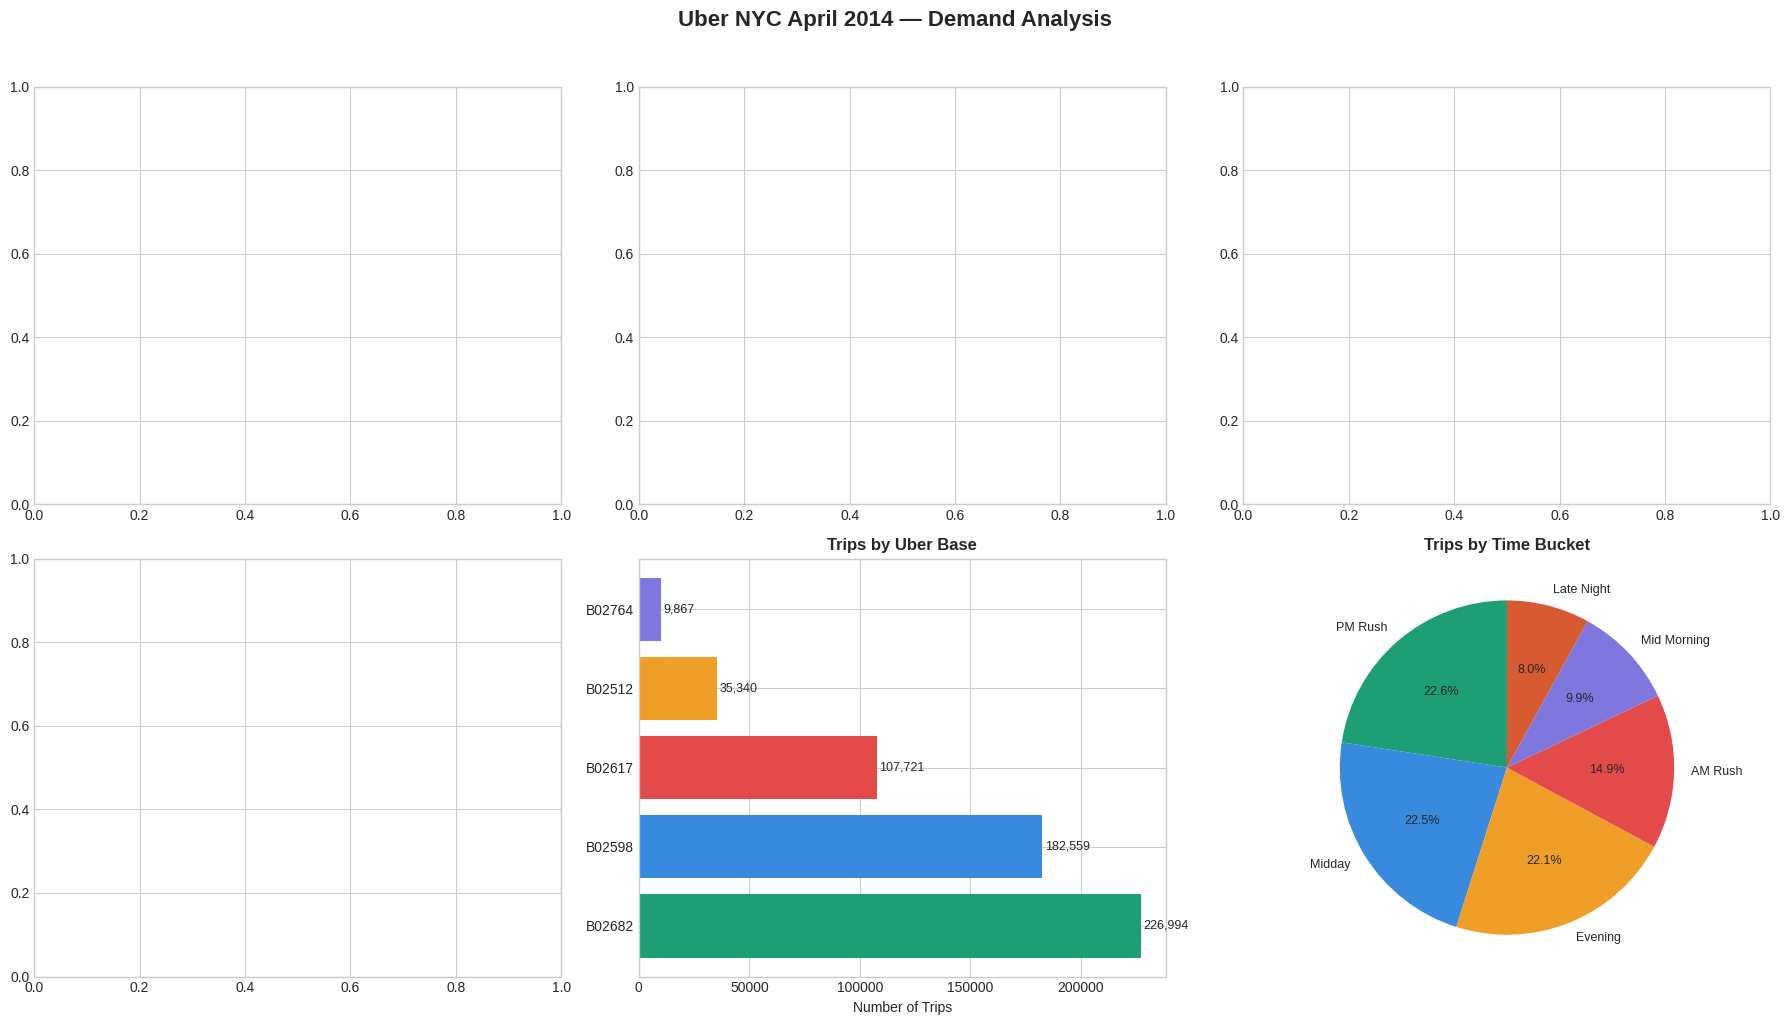

 EDA plot saved as 'uber_eda.png'


In [82]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Uber NYC April 2014 — Demand Analysis', fontsize=16, fontweight='bold', y=1.02)
# Plot 5: Base activity comparison
base_counts = df['Base'].value_counts()
axes[1,1].barh(base_counts.index, base_counts.values,
                color=['#1D9E75', '#378ADD', '#E24B4A', '#EF9F27', '#7F77DD'])
axes[1,1].set_title('Trips by Uber Base', fontweight='bold')
axes[1,1].set_xlabel('Number of Trips')
for i, v in enumerate(base_counts.values):
    axes[1,1].text(v + 1000, i, f'{v:,}', va='center', fontsize=9)

# Plot 6: Time bucket distribution
bucket_counts = df['time_bucket'].value_counts()
wedge_colors = ['#1D9E75','#378ADD','#EF9F27','#E24B4A','#7F77DD','#D85A30']
axes[1,2].pie(bucket_counts.values, labels=bucket_counts.index,
               autopct='%1.1f%%', colors=wedge_colors, startangle=90,
               textprops={'fontsize': 9})
axes[1,2].set_title('Trips by Time Bucket', fontweight='bold')

plt.tight_layout()
plt.savefig('uber_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(" EDA plot saved as 'uber_eda.png'")

Geographic Visualization

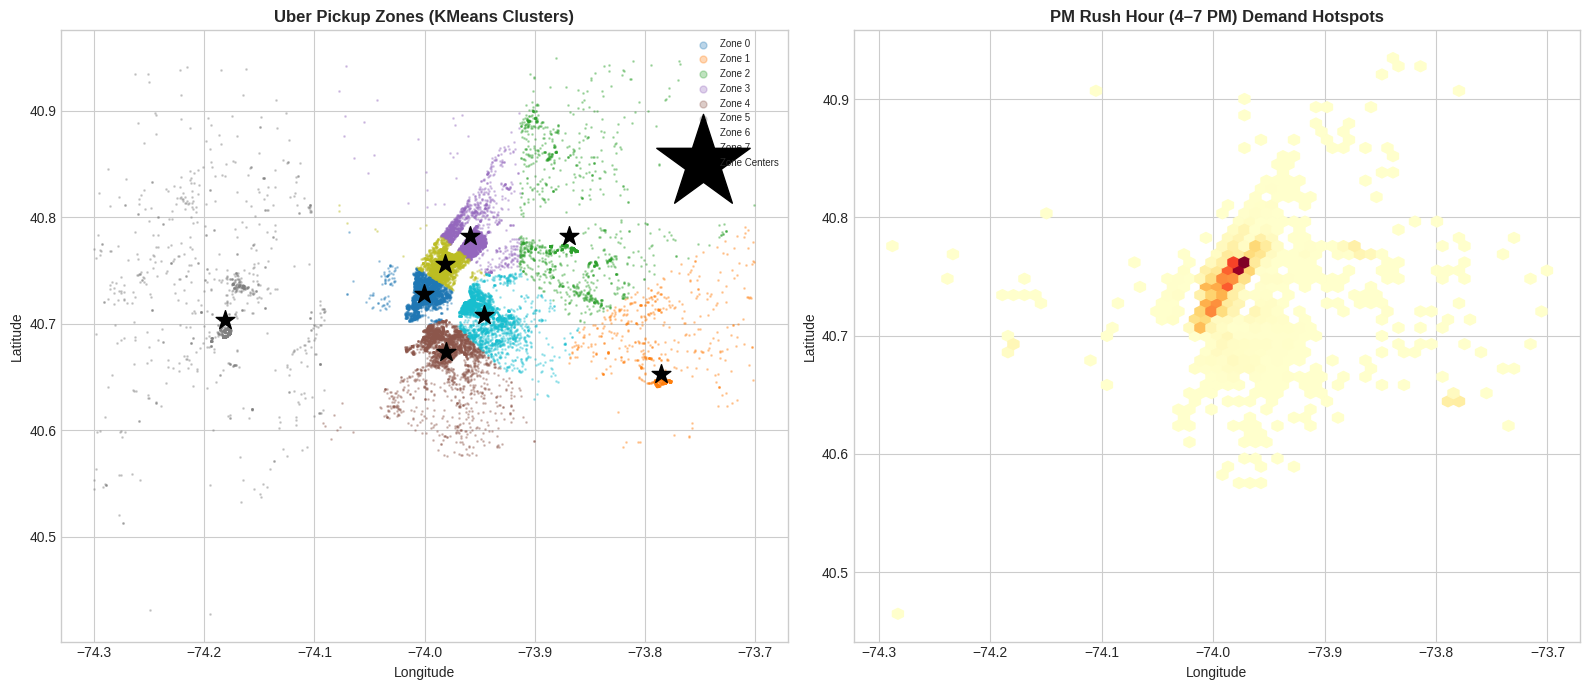

 Geographic plot saved as 'uber_geo.png'


In [85]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Scatter by zone
zone_colors = plt.cm.tab10(np.linspace(0, 1, 8))
for zone_id in range(8):
    zone_data = df[df['zone'] == zone_id].sample(min(3000, len(df[df['zone'] == zone_id])))
    axes[0].scatter(zone_data['Lon'], zone_data['Lat'],
                    c=[zone_colors[zone_id]], s=1, alpha=0.3, label=f'Zone {zone_id}')

centers = kmeans.cluster_centers_
axes[0].scatter(centers[:, 1], centers[:, 0], c='black', s=200,
                marker='*', zorder=5, label='Zone Centers')
axes[0].set_title('Uber Pickup Zones (KMeans Clusters)', fontweight='bold')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].legend(fontsize=7, markerscale=5)
# Right: PM Rush hour heatmap
rush_df = df[df['is_rush_pm'] == 1].sample(10000)
axes[1].hexbin(rush_df['Lon'], rush_df['Lat'], gridsize=60,
               cmap='YlOrRd', mincnt=1)
axes[1].set_title('PM Rush Hour (4–7 PM) Demand Hotspots', fontweight='bold')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
plt.savefig('uber_geo.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Geographic plot saved as 'uber_geo.png'")
